# 🛒 Market Basket Analysis — Apriori Algorithm
**Dataset:** Market_Basket_Optimisation.csv — 7,501 real retail transactions

**Goal:** Discover which products are frequently bought together and generate actionable association rules.

---
### 📋 Steps:
1. Install required libraries
2. Load and explore the dataset
3. Preprocess data (One-Hot Encoding)
4. Apply the Apriori algorithm → Frequent Itemsets
5. Generate Association Rules (Support, Confidence, Lift)
6. Sort rules by Lift → strongest associations
7. Export results to CSV
8. Visualize associations

---
## Step 1 — Install Required Libraries

In [2]:
pip install mlxtend --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 2 — Import Libraries & Load Dataset

The CSV has **no header row** — each row is one transaction, each column is one item slot.
Some slots are empty (NaN) because transactions have different lengths.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load the dataset — no header, each row = one basket
df_raw = pd.read_csv('Market_Basket_Optimisation.csv', header=None)

print(f'Dataset loaded successfully!')
print(f'   Transactions : {df_raw.shape[0]:,}')
print(f'   Max columns  : {df_raw.shape[1]} (item slots per transaction)')
print()
df_raw.head(10)

Dataset loaded successfully!
   Transactions : 7,501
   Max columns  : 20 (item slots per transaction)



,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,whole wheat pasta,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,soup,light cream,shallot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,frozen vegetables,spaghetti,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Step 3 — Preprocess: Clean & One-Hot Encode

We convert each row into a Python list (dropping NaN values), then use `TransactionEncoder` to build a boolean matrix where:
- **Row** = one transaction
- **Column** = one unique product
- **True** = product was purchased

In [4]:
# Convert each row to a list, dropping NaN values
transactions = []
for _, row in df_raw.iterrows():
    basket = [str(item).strip() for item in row if pd.notna(item)]
    if basket:
        transactions.append(basket)

print(f'{len(transactions):,} valid transactions prepared')

all_items = [item for basket in transactions for item in basket]
unique_items = sorted(set(all_items))
print(f'{len(unique_items)} unique products found')
print(f'Average basket size: {len(all_items)/len(transactions):.1f} items')

7,501 valid transactions prepared
119 unique products found
Average basket size: 3.9 items


In [5]:
# One-Hot Encode using TransactionEncoder
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded matrix shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(5)

Encoded matrix shape: 7,501 rows x 119 columns


,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,True,True,False,True,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [6]:
# Item frequency overview — top 20 most purchased items
item_freq = df.sum().sort_values(ascending=False)
item_support = (item_freq / len(df)).round(4)

freq_overview = pd.DataFrame({
    'Item': item_freq.index,
    'Frequency': item_freq.values,
    'Support': item_support.values
})

print('Top 20 Most Purchased Items:')
freq_overview.head(20)

Top 20 Most Purchased Items:


,Item,Frequency,Support
0,mineral water,1788,0.2384
1,eggs,1348,0.1797
2,spaghetti,1306,0.1741
3,french fries,1282,0.1709
4,chocolate,1229,0.1638
5,green tea,991,0.1321
6,milk,972,0.1296
7,ground beef,737,0.0983
8,frozen vegetables,715,0.0953
9,pancakes,713,0.0951


---
## Step 4 — Apply the Apriori Algorithm → Frequent Itemsets

### Key Concept — Support:
> **Support(A)** = Transactions containing A / Total transactions

We use `min_support = 0.02` → itemset must appear in at least **2%** of transactions (~150 out of 7,501).
This is the right balance for a large real-world dataset with many products.

In [7]:
# Apply Apriori
frequent_itemsets = apriori(
    df,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f'Found {len(frequent_itemsets)} frequent itemsets')
print()
print('Breakdown by itemset size:')
print(frequent_itemsets['itemset_size'].value_counts().sort_index().to_string())
print()
frequent_itemsets.head(15)

Found 103 frequent itemsets

Breakdown by itemset size:
itemset_size
1    53
2    50



,support,itemsets,itemset_size
0,0.238368,(mineral water),1
1,0.179709,(eggs),1
2,0.174110,(spaghetti),1
3,0.170911,(french fries),1
4,0.163845,(chocolate),1
5,0.132116,(green tea),1
6,0.129583,(milk),1
7,0.098254,(ground beef),1
8,0.095321,(frozen vegetables),1
9,0.095054,(pancakes),1


---
## Step 5 — Generate Association Rules

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Support** | P(A and B) | How often A and B appear together |
| **Confidence** | P(B given A) | When A is bought, how likely is B? |
| **Lift** | Confidence / P(B) | Lift > 1 = real positive association |

We use `min_confidence = 0.2` so rules must be correct at least 20% of the time.

In [8]:
# Generate association rules
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.2
)

# Keep key columns
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

# Convert frozensets to readable strings
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'Generated {len(rules)} association rules')
print()
rules.head(10)

Generated 55 association rules



,antecedents,consequents,support,confidence,lift
0,spaghetti,mineral water,0.059725,0.343032,1.439085
1,mineral water,spaghetti,0.059725,0.250559,1.439085
2,chocolate,mineral water,0.052660,0.321400,1.348332
3,mineral water,chocolate,0.052660,0.220917,1.348332
4,mineral water,eggs,0.050927,0.213647,1.188845
5,eggs,mineral water,0.050927,0.283383,1.188845
6,mineral water,milk,0.047994,0.201342,1.553774
7,milk,mineral water,0.047994,0.370370,1.553774
8,ground beef,mineral water,0.040928,0.416554,1.747522
9,spaghetti,ground beef,0.039195,0.225115,2.291162


---
## Step 6 — Sort Rules by Lift (Strongest Associations First)

> **Lift > 1** = Positive association — buying A increases chance of buying B  
> **Lift = 1** = No relationship  
> **Lift < 1** = Negative association

In [9]:
rules_sorted = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print('Top 15 Strongest Association Rules (by Lift):')
print()
rules_sorted.head(15).round(4)

Top 15 Strongest Association Rules (by Lift):



,antecedents,consequents,support,confidence,lift
0,spaghetti,ground beef,0.0392,0.2251,2.2912
1,ground beef,spaghetti,0.0392,0.3989,2.2912
2,olive oil,spaghetti,0.0229,0.3482,1.9998
3,soup,mineral water,0.0231,0.4565,1.9150
4,frozen vegetables,milk,0.0236,0.2476,1.9104
5,burgers,eggs,0.0288,0.3303,1.8378
6,olive oil,mineral water,0.0276,0.4190,1.7579
7,tomatoes,spaghetti,0.0209,0.3060,1.7578
8,ground beef,mineral water,0.0409,0.4166,1.7475
9,ground beef,milk,0.0220,0.2239,1.7277


---
## Step 7 — Export Results to CSV

In [10]:
# Export frequent itemsets
export_itemsets = frequent_itemsets.copy()
export_itemsets['itemsets'] = export_itemsets['itemsets'].apply(lambda x: ', '.join(sorted(x)))
export_itemsets.to_csv('frequent_itemsets.csv', index=False)

# Export association rules
rules_sorted.to_csv('association_rules.csv', index=False)

print('Files saved:')
print('   frequent_itemsets.csv')
print('   association_rules.csv')

Files saved:
   frequent_itemsets.csv
   association_rules.csv


---
## Step 8 — Visualizations

### Chart 1: Top 15 Most Purchased Items

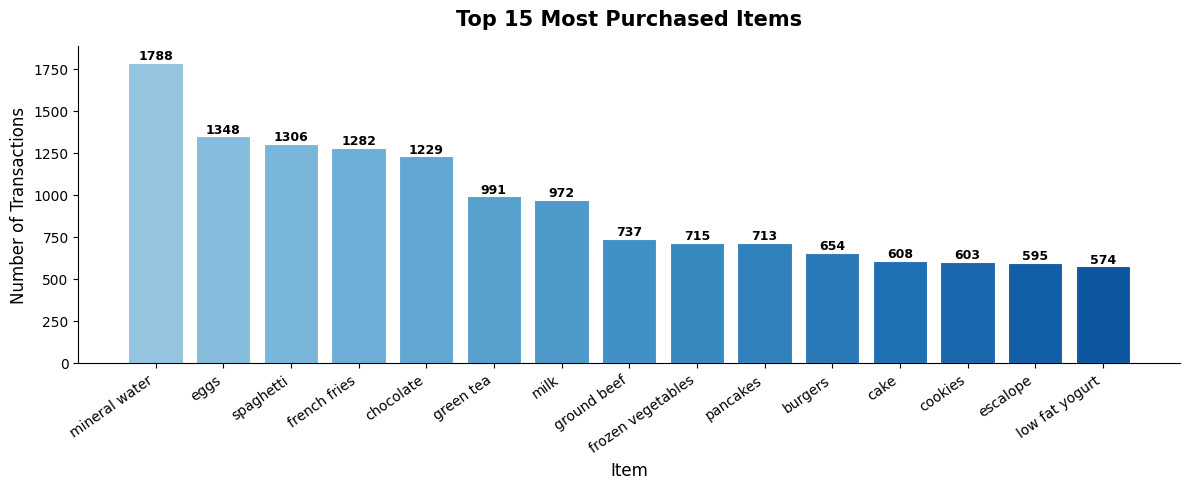

In [11]:
top15_items = item_freq.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(top15_items)))
bars = ax.bar(top15_items.index, top15_items.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, top15_items.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title('Top 15 Most Purchased Items', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Item', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_ylim(0, top15_items.max() + 100)
plt.xticks(rotation=35, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart1_item_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 2: Support vs Confidence Scatter (bubble size = Lift)

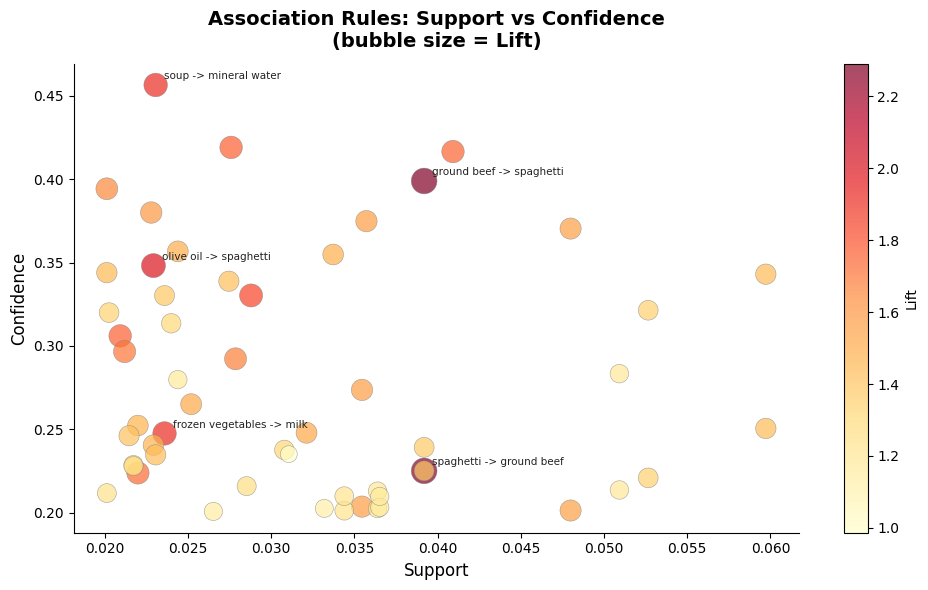

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    rules_sorted['support'],
    rules_sorted['confidence'],
    s=rules_sorted['lift'] * 150,
    c=rules_sorted['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    edgecolors='gray',
    linewidth=0.4
)

plt.colorbar(scatter, ax=ax, label='Lift')

for _, row in rules_sorted.head(5).iterrows():
    label = f"{row['antecedents']} -> {row['consequents']}"
    ax.annotate(label, (row['support'], row['confidence']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7.5, color='#222222')

ax.set_title('Association Rules: Support vs Confidence\n(bubble size = Lift)', 
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_support_confidence_lift.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 3: Top 10 Rules by Lift — Horizontal Bar Chart

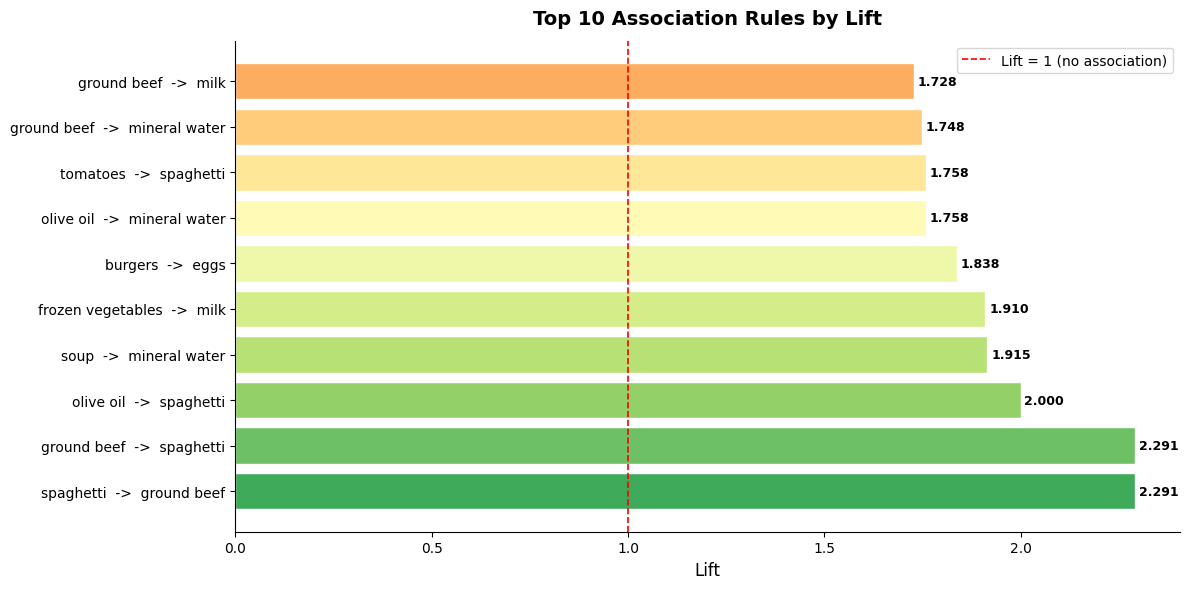

In [13]:
top10 = rules_sorted.head(10).copy()
top10['rule'] = top10['antecedents'] + '  ->  ' + top10['consequents']

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.85, len(top10)))
bars = ax.barh(top10['rule'], top10['lift'], color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, top10['lift']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

ax.axvline(x=1, color='red', linestyle='--', linewidth=1.2, label='Lift = 1 (no association)')
ax.set_title('Top 10 Association Rules by Lift', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Lift', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_top10_lift.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Lift Heatmap — Top Rule Pairs

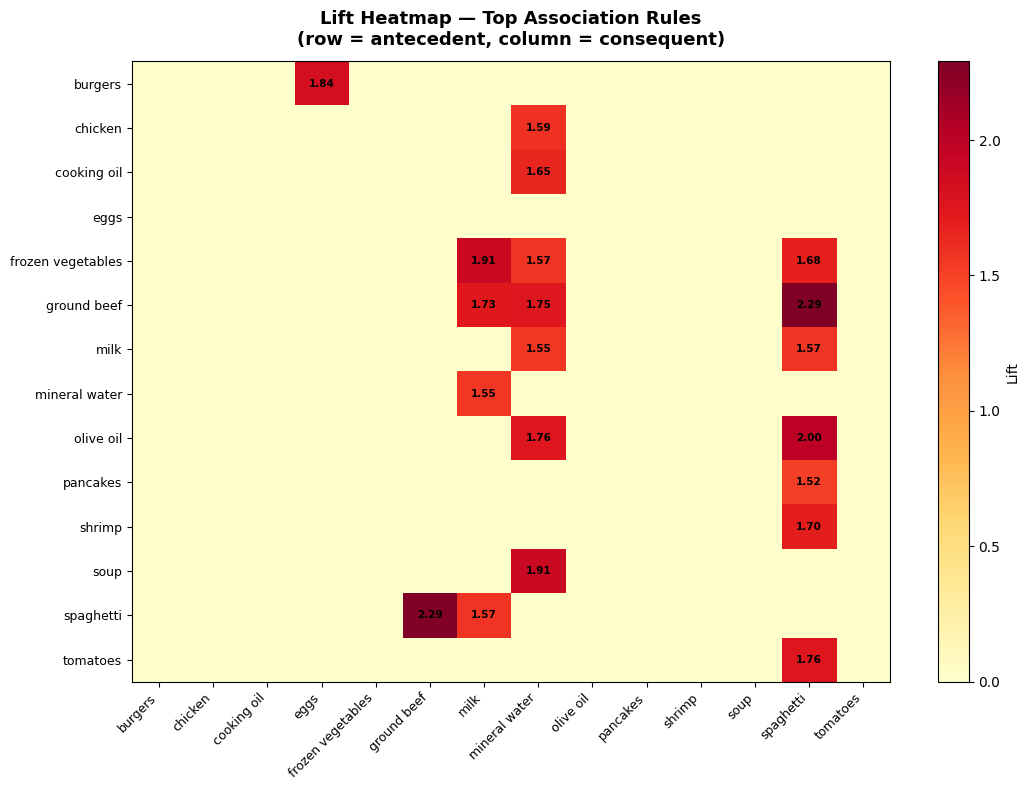

In [14]:
top_rules = rules_sorted.head(20)
pivot_items = sorted(set(top_rules['antecedents'].tolist() + top_rules['consequents'].tolist()))

heatmap_data = pd.DataFrame(0.0, index=pivot_items, columns=pivot_items)

for _, row in top_rules.iterrows():
    a, c = row['antecedents'], row['consequents']
    if a in pivot_items and c in pivot_items:
        heatmap_data.loc[a, c] = round(row['lift'], 2)

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(heatmap_data.values.astype(float), cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Lift')

ax.set_xticks(range(len(pivot_items)))
ax.set_yticks(range(len(pivot_items)))
ax.set_xticklabels(pivot_items, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(pivot_items, fontsize=9)

for i in range(len(pivot_items)):
    for j in range(len(pivot_items)):
        val = float(heatmap_data.values[i, j])
        if val > 0:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, fontweight='bold')

ax.set_title('Lift Heatmap — Top Association Rules\n(row = antecedent, column = consequent)', 
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('chart4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary & Business Insights

### What We Found:
- **7,501 real transactions** were analyzed
- Frequent itemsets reveal the most common product combinations in the store
- Association rules sorted by **Lift** show the strongest product relationships

### How to Read the Rules:
| Metric | Good Value | Meaning |
|--------|-----------|--------|
| Support | > 0.02 | Combination appears frequently |
| Confidence | > 0.3 | Rule is reliable |
| **Lift** | **> 1.5** | **Strong, meaningful association** |

### Business Applications:
- **Store layout:** Place high-lift item pairs near each other
- **Promotions:** Bundle products with strong associations
- **Recommendation engine:** Customers who bought X also bought Y
- **Inventory planning:** Stock associated items together

### Tuning Tips:
- Lower `min_support` -> more itemsets found, but slower
- Raise `min_confidence` -> fewer but more reliable rules
- Focus on rules with **Lift > 1.5** for actionable insights